# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

### Read Dataset

In [5]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Cleaning

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Drop Unusual Columns

In [11]:
## Remove Unusual Columns
df = df.drop('PassengerId', axis=1)
# df = df.drop('Age', axis=1)
df = df.drop('Cabin', axis=1)

In [12]:
## mode use kiya qn ka ya categorical data thaaa or 2 null thee replace them with mode anf [0] is first mode value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [14]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [15]:
df['Ticket'].value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

In [16]:
df.duplicated().copy()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [17]:
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [18]:
df['Name'] = df['Name'].str.split().str[2:4].str.join(' ')
df['Name']

0          Owen Harris
1         John Bradley
2                Laina
3        Jacques Heath
4        William Henry
            ...       
886             Juozas
887     Margaret Edith
888    Catherine Helen
889        Karl Howell
890            Patrick
Name: Name, Length: 891, dtype: object

In [19]:
df.shape

(891, 10)

In [20]:
df = df.drop(['Name','Ticket'], axis=1)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [22]:
## Analysis
# S → Southampton
# C → Cherbourg
# Q → Queenstown

## Feature Engineering

In [23]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    object 
 8   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [25]:
df['Age'].value_counts

<bound method IndexOpsMixin.value_counts of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64>

## Feature Analysis

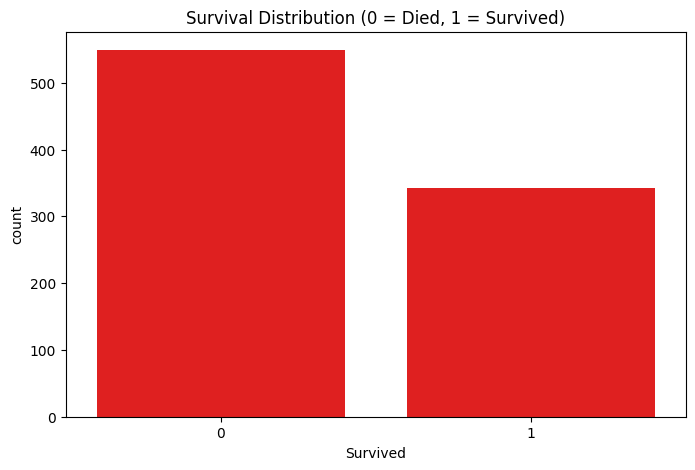

In [27]:
from pathlib import Path
import seaborn as sns
from pathlib import Path
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df, color = 'red')
plt.title("Survival Distribution (0 = Died, 1 = Survived)")



output_folder = Path("Survival_Distribution_Analysis")
output_folder.mkdir(exist_ok=True)

# Chart banane ke baad:
plt.savefig(
    output_folder / "01_Survival_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


plt.show()


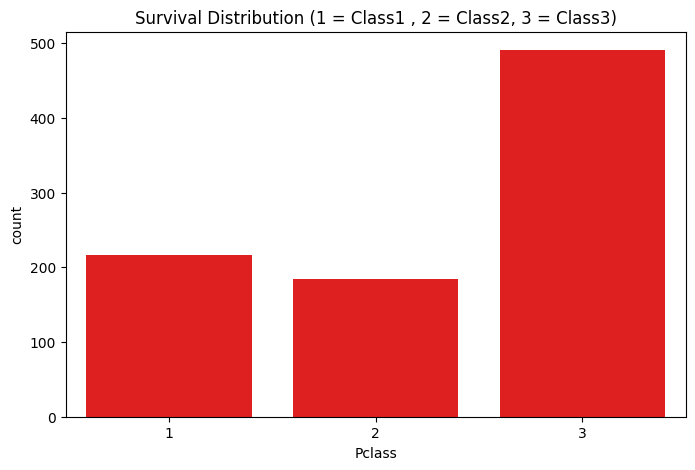

In [28]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', data=df, color='red')
plt.title("Survival Distribution (1 = Class1 , 2 = Class2, 3 = Class3)")

# Chart banane ke baad:
plt.savefig(
    output_folder / "02_PClass_Survival_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

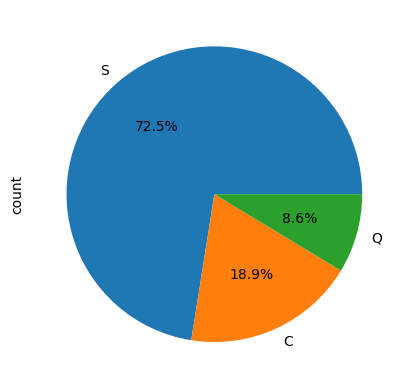

In [30]:
fig = df["Embarked"].value_counts().plot.pie(autopct="%1.1f%%")

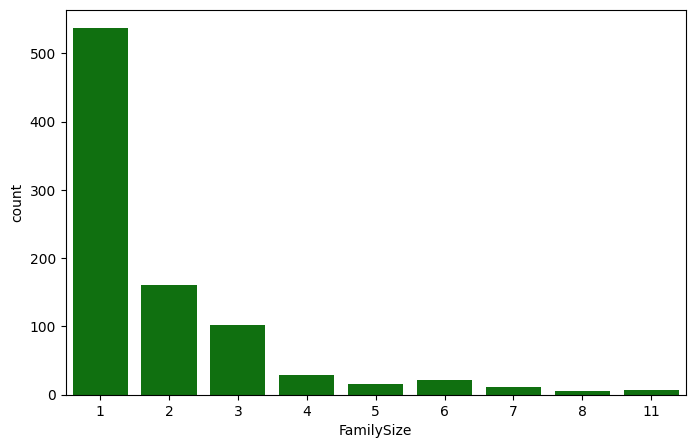

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='FamilySize', data=df, color='green')
plt.title("")
plt.show()


In [32]:
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

# Analysis in between two columns

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    object 
 8   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [34]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder()
one_hot= pd.get_dummies(df, columns=["Embarked"], dtype=int)

print(one_hot)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare  FamilySize  \
0           0       3    male  22.0      1      0   7.2500           2   
1           1       1  female  38.0      1      0  71.2833           2   
2           1       3  female  26.0      0      0   7.9250           1   
3           1       1  female  35.0      1      0  53.1000           2   
4           0       3    male  35.0      0      0   8.0500           1   
..        ...     ...     ...   ...    ...    ...      ...         ...   
886         0       2    male  27.0      0      0  13.0000           1   
887         1       1  female  19.0      0      0  30.0000           1   
888         0       3  female  28.0      1      2  23.4500           4   
889         1       1    male  26.0      0      0  30.0000           1   
890         0       3    male  32.0      0      0   7.7500           1   

     Embarked_C  Embarked_Q  Embarked_S  
0             0           0           1  
1             1           0

In [35]:
### To check which Pclass have more chances to servive
survived_by_Pclass = df.groupby('Pclass')['Survived'].sum()
survived_by_Pclass = survived_by_Pclass.sort_values(ascending=False)
print(survived_by_Pclass)


Pclass
1    136
3    119
2     87
Name: Survived, dtype: int64


<Axes: title={'center': 'Survivors by Passenger Class'}, xlabel='Pclass'>

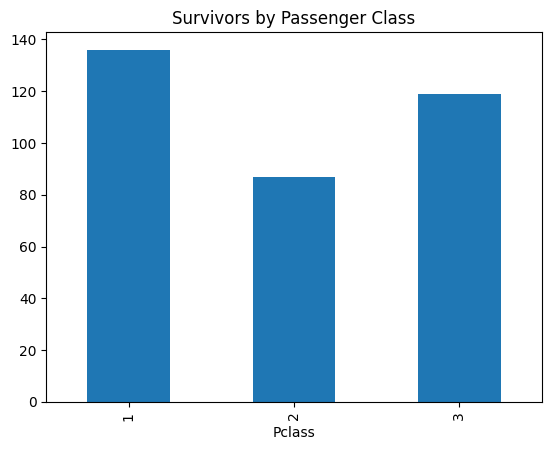

In [36]:
import numpy as np
plt.title("Survived By Pclass")
x = np.array(df['Pclass'])
y = np.array(df['Survived'])

survivors = df[df["Survived"] == 1]
survivors["Pclass"].value_counts().sort_index().plot(
    kind="bar", title="Survivors by Passenger Class"
)
## the reason of this is to check how many passengers alive and belong to which class

In [37]:
# Embarked
# survuved
### To check which Embarked have more chances to servive
plt.figure(figsize=(5,8))
survived_by_embarked = df.groupby('Embarked')['Survived'].sum()
survived_by_embarked = survived_by_embarked.sort_values(ascending=False)
print(survived_by_embarked)

Embarked
S    219
C     93
Q     30
Name: Survived, dtype: int64


<Figure size 500x800 with 0 Axes>

<Axes: title={'center': 'Survivors By Embarked'}, xlabel='Embarked'>

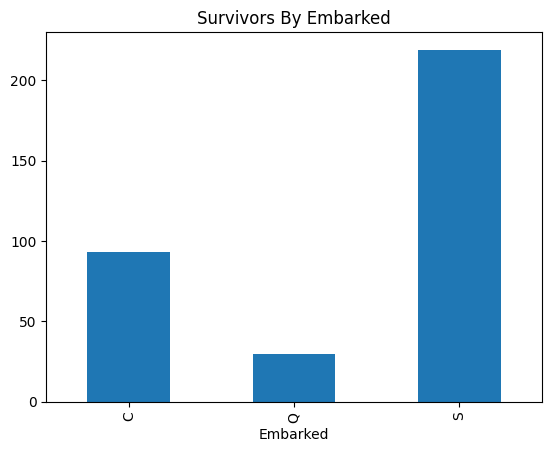

In [47]:
plt.title('Survived By Embarked')
x = np.array(df['Embarked'])
y = np.array(df['Survived'])
survivors = df[df['Survived'] == 1]
survivors['Embarked'].value_counts().sort_index().plot(
    kind = 'bar', title = "Survivors By Embarked")

In [39]:
plt.figure(figsize=(5,8))
survived_by_sex = df.groupby('Sex')['Survived'].sum()
survived_by_sex = survived_by_sex.sort_values(ascending=False)
print(survived_by_sex)

Sex
female    233
male      109
Name: Survived, dtype: int64


<Figure size 500x800 with 0 Axes>

<Axes: title={'center': 'Survivors By Sex'}, xlabel='Sex'>

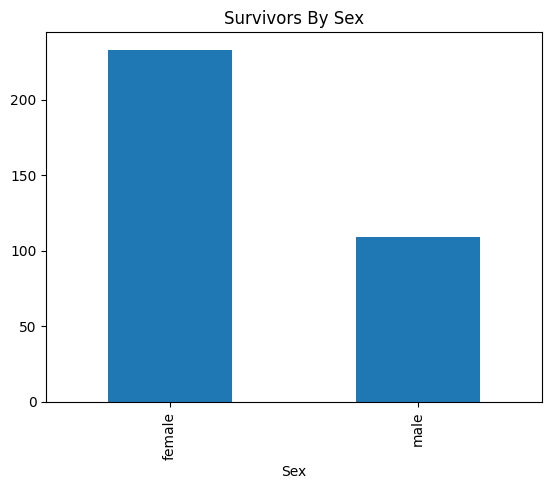

In [40]:
plt.title("Survived By Sex")
x = np.array(df['Sex'])
y = np.array(df['Survived'])
survivors = df[df['Survived'] == 1]
survivors['Sex'].value_counts().sort_index().plot(
    kind = 'bar', title = "Survivors By Sex")

In [43]:
plt.figure(figsize=(5, 8))
survived_by_family_size = df.groupby('FamilySize')['Survived'].sum()
survived_by_family_size = survived_by_family_size.sort_values(ascending=False)

<Figure size 500x800 with 0 Axes>

<Axes: title={'center': 'Survivors By Family Size'}, xlabel='FamilySize'>

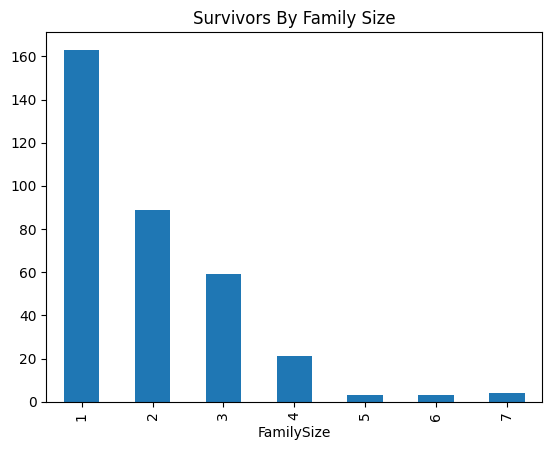

In [44]:
plt.title('Survived By Family Size')
x = np.array(df['FamilySize'])
y = np.array(['Survived'])
survivors = df[df['Survived'] == 1]
survivors['FamilySize'].value_counts().sort_index().plot(
    kind = 'bar', title = "Survivors By Family Size"
)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    object 
 8   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [ ]:
cleaned_titanic__dataset = df[['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'FamilySize']].copy()

# Nayi file apne folder mein save karein
cleaned_titanic__dataset.to_csv("cleaned_titanic__dataset.csv", index=False)